# E-Commerce Return Fraud Detection


## Data Quality Assessment 




In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv(r'D:\projects\commerce dataset\E-commerce\data\raw\ecommerce_return_fraud_dataset.csv')

## 1. Missing Value Analysis



In [3]:

print("MISSING VALUE ANALYSIS")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_percent.values,
    'Data Type': df.dtypes.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values('Missing Percentage', ascending=False)
missing_df = missing_df.reset_index(drop=True)

print(missing_df.to_string())

MISSING VALUE ANALYSIS
            Column  Missing Count  Missing Percentage Data Type
0  customer_rating           7575           15.000000   float64
1     customer_age           7529           14.908911   float64
2  membership_type           6750           13.366337       str
3    product_price           6516           12.902970       str


## 2. Duplicate Record Detection

Identifying fully duplicate rows and duplicate `order_id` values to prevent data leakage and inflated model metrics.

In [4]:
full_duplicates = df.duplicated().sum()
print(f"Fully duplicate rows: {full_duplicates}")

order_id_dups = df['order_id'].duplicated().sum()
print(f"Duplicate order_ids: {order_id_dups}")

customer_id_dups = df['customer_id'].duplicated().sum()
print(f"Customers with multiple orders: {customer_id_dups}")

if order_id_dups > 0:
    print("\nDuplicate Order ID Records:")
    dup_orders = df[df['order_id'].duplicated(keep=False)]
    print(dup_orders[['order_id', 'customer_id', 'order_amount', 'return_fraud']])

Fully duplicate rows: 500
Duplicate order_ids: 500
Customers with multiple orders: 500

Duplicate Order ID Records:
         order_id customer_id  order_amount  return_fraud
147    ORD0000147  CUST000147   4821.564998             1
199    ORD0000199  CUST000199  48274.501724             0
262    ORD0000262  CUST000262  27178.542198             1
292    ORD0000292  CUST000292  19666.532273             1
314    ORD0000314  CUST000314  50636.363043             1
...           ...         ...           ...           ...
50495  ORD0000314  CUST000314  50636.363043             1
50496  ORD0011449  CUST011449   1309.682598             1
50497  ORD0030745  CUST030745  30575.717549             0
50498  ORD0029702  CUST029702  16283.838162             1
50499  ORD0027658  CUST027658  46406.562413             1

[1000 rows x 4 columns]


500 fully duplicate rows must be dropped — they inflate training set size and skew class balance. The matching 500 duplicate `order_id` values suggest pipeline re-ingestion; review each before removal to determine whether any are legitimate re-order events rather than data errors.

## 3. Data Type Verification

Validating that column dtypes match expected types. `product_price` and `discount_percent` are stored as `str` due to mixed symbol encoding (₹ prefix, % suffix).

In [21]:
print("DTYPES OF SUSPECT COLUMNS \n")
print(df.dtypes)
print("product_price    :", df['product_price'].dtype)
print("discount_percent :", df['discount_percent'].dtype)
print("order_date       :", df['order_date'].dtype)
print()
print("product_price samples    :", df['product_price'].dropna().unique()[:4])
print("discount_percent samples :", df['discount_percent'].dropna().unique()[:4])

DTYPES OF SUSPECT COLUMNS 

order_id                          str
customer_id                       str
customer_age                  float64
gender                            str
city_tier                         str
membership_type                   str
account_age_days                int64
total_orders                    int64
previous_returns                int64
return_rate                   float64
product_category                  str
product_price                     str
discount_percent                  str
order_amount                  float64
payment_method                    str
delivery_days                   int64
return_reason                     str
days_to_return                  int64
customer_rating               float64
customer_support_tickets        int64
device_type                       str
ip_risk_score                   int64
order_date                        str
delivery_date                     str
return_request_date               str
refund_processed_date 

In [7]:

print("Rows where product_price has ₹ symbol:")
rupee_rows = df[df['product_price'].astype(str).str.contains('₹', na=False)]
print(f"Count: {len(rupee_rows)}")
print(rupee_rows[['order_id', 'product_price']].head())


print("Rows where discount_percent has % symbol:")
percent_rows = df[df['discount_percent'].astype(str).str.contains('%', na=False)]
print(f"Count: {len(percent_rows)}")
print(percent_rows[['order_id', 'discount_percent']].head())

Rows where product_price has ₹ symbol:
Count: 7046
      order_id product_price
0   ORD0000000        ₹39922
14  ORD0000014        ₹15278
15  ORD0000015        ₹82429
28  ORD0000028        ₹67075
38  ORD0000038            ₹0
Rows where discount_percent has % symbol:
Count: 7057
      order_id discount_percent
2   ORD0000002           48.32%
5   ORD0000005           19.64%
17  ORD0000017           46.28%
32  ORD0000032            4.71%
33  ORD0000033           28.88%


## 4. Invalid Value Identification

Detecting values that are logically or statistically impossible: `return_rate > 1.0`, sentinel prices (₹9,99,99,999), zero prices, and out-of-range customer ages.

In [8]:
print("INVALID VALUE DETECTION")


print("\nreturn_rate statistics:")
print(df['return_rate'].describe())

invalid_return_rate = df[df['return_rate'] > 1.0]
print(f"\nRows where return_rate > 1.0 (IMPOSSIBLE): {len(invalid_return_rate)}")
print(invalid_return_rate[['order_id', 'customer_id', 
                            'total_orders', 'previous_returns', 
                            'return_rate']].head())

INVALID VALUE DETECTION

return_rate statistics:
count    50500.000000
mean         0.697114
std          2.299785
min          0.000000
25%          0.119197
50%          0.243902
75%          0.487500
max         49.000000
Name: return_rate, dtype: float64

Rows where return_rate > 1.0 (IMPOSSIBLE): 5935
      order_id customer_id  total_orders  previous_returns  return_rate
10  ORD0000010  CUST000010            48                49     1.020833
11  ORD0000011  CUST000011            27                44     1.629630
12  ORD0000012  CUST000012             2                19     9.500000
14  ORD0000014  CUST000014            22                24     1.090909
24  ORD0000024  CUST000024            10                49     4.900000


In [9]:

df_temp = df.copy()
df_temp['product_price_clean'] = df_temp['product_price'].astype(str)\
    .str.replace('₹', '', regex=False)\
    .str.replace(',', '', regex=False)\
    .str.strip()

df_temp['product_price_clean'] = pd.to_numeric(
    df_temp['product_price_clean'], errors='coerce'
)

print("product_price statistics (after cleaning symbols):")
print(df_temp['product_price_clean'].describe())

# Suspicious values — too high or zero
print("\nSuspiciously HIGH prices (> 1,00,000):")
high_price = df_temp[df_temp['product_price_clean'] > 100000]
print(f"Count: {len(high_price)}")
print(high_price[['order_id', 'product_price']].head())

print("\nZero prices (price = 0):")
zero_price = df_temp[df_temp['product_price_clean'] == 0]
print(f"Count: {len(zero_price)}")
print(zero_price[['order_id', 'product_price']].head())

product_price statistics (after cleaning symbols):
count    4.398400e+04
mean     1.649238e+05
std      3.401684e+06
min     -5.000000e+03
25%      2.380450e+04
50%      4.908600e+04
75%      7.455125e+04
max      1.000000e+08
Name: product_price_clean, dtype: float64

Suspiciously HIGH prices (> 1,00,000):
Count: 51
        order_id product_price
3161  ORD0003161      99999999
4338  ORD0004338      99999999
5418  ORD0005418      99999999
5758  ORD0005758      99999999
6119  ORD0006119      99999999

Zero prices (price = 0):
Count: 1026
       order_id product_price
38   ORD0000038            ₹0
57   ORD0000057            ₹0
74   ORD0000074            ₹0
119  ORD0000119            ₹0
122  ORD0000122            ₹0


In [10]:
#customer_age Invalid Values
print("customer_age statistics:")
print(df['customer_age'].describe())

print("\nSuspicious ages (< 18 or > 100):")
suspicious_age = df[
    (df['customer_age'] < 18) | (df['customer_age'] > 100)
]
print(f"Count: {len(suspicious_age)}")
print(suspicious_age[['order_id', 'customer_age']].head())

customer_age statistics:
count    42971.000000
mean        43.718880
std         16.944463
min        -10.000000
25%         31.000000
50%         43.000000
75%         56.000000
max        200.000000
Name: customer_age, dtype: float64

Suspicious ages (< 18 or > 100):
Count: 201
        order_id  customer_age
412   ORD0000412         200.0
552   ORD0000552         -10.0
717   ORD0000717         -10.0
1297  ORD0001297         200.0
1906  ORD0001906         -10.0


**Insight:** 5,935 rows have `return_rate > 1.0` (max: 49×) — `previous_returns` exceeds `total_orders`, which is a calculation error. The 1,026 zero-price and 51 sentinel-price (99999999) rows are placeholder values from data collection. Customer ages of −10 and 200 (201 rows) are deliberate corruption — delete, do not impute.

---

## 5. Categorical Consistency Check

Flagging non-standard labels, case variants, and abbreviations that must be normalised before one-hot encoding.

In [11]:
print("INCONSISTENT CATEGORICAL VALUES")

print("\n--- GENDER column ---")
print(df['gender'].value_counts())
print("\nExpected values: Male, Female")
print("Issues found: M, male, MALE, Female, female etc.")

INCONSISTENT CATEGORICAL VALUES

--- GENDER column ---
gender
Male      23655
Female    22666
male       1428
MALE       1398
M          1353
Name: count, dtype: int64

Expected values: Male, Female
Issues found: M, male, MALE, Female, female etc.


In [12]:
print("\n--- MEMBERSHIP TYPE column ---")
print(df['membership_type'].value_counts())
print("\nExpected: Silver, Gold, Platinum")
print("Issues: GOLD, gold, Gld, SILVER, PLATINUM etc.")


--- MEMBERSHIP TYPE column ---
membership_type
Gold        14144
Silver      12955
Platinum    12889
GOLD         1279
Gld          1249
gold         1234
Name: count, dtype: int64

Expected: Silver, Gold, Platinum
Issues: GOLD, gold, Gld, SILVER, PLATINUM etc.


**Insight:** `gender` has 3 non-standard variants (`M`, `male`, `MALE`) representing ~8.2% of records — all map to `Male`. `membership_type` carries 3 variants (`Gld`, `GOLD`, `gold`) adding ~8.5% noise on top of 13.4% NaN. The remaining 8 categoricals (`city_tier`, `payment_method`, `product_category`, `return_reason`, `device_type`, `fraud_investigation_status`, `refund_approved`, `final_fraud_decision`) are fully clean and ready for encoding.

### 5.1 Full Categorical Audit — All Columns

Exhaustive check of every categorical column for unexpected values, case variants, and NaN distribution.

In [13]:
# Unique value distribution for every categorical column
cat_cols = ['gender', 'membership_type', 'city_tier',
            'product_category', 'payment_method',
            'return_reason', 'device_type',
            'fraud_investigation_status', 'refund_approved',
            'final_fraud_decision']

print("ALL CATEGORICAL COLUMNS — UNIQUE VALUES")

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))
    print(f"  -> Unique count: {df[col].nunique()}")

ALL CATEGORICAL COLUMNS — UNIQUE VALUES

gender:
gender
Male      23655
Female    22666
male       1428
MALE       1398
M          1353
Name: count, dtype: int64
  -> Unique count: 5

membership_type:
membership_type
Gold        14144
Silver      12955
Platinum    12889
NaN          6750
GOLD         1279
Gld          1249
gold         1234
Name: count, dtype: int64
  -> Unique count: 6

city_tier:
city_tier
Tier1    16913
Tier2    16813
Tier3    16774
Name: count, dtype: int64
  -> Unique count: 3

product_category:
product_category
Furniture      8513
Electronics    8510
Appliances     8384
Mobile         8374
Fashion        8361
Books          8358
Name: count, dtype: int64
  -> Unique count: 6

payment_method:
payment_method
Debit Card     10167
Credit Card    10129
UPI            10123
Net Banking    10049
COD            10032
Name: count, dtype: int64
  -> Unique count: 5

return_reason:
return_reason
Size Issue       10253
Not Needed       10150
Quality Issue    10141
Damaged   

## 6. Date Format Analysis

Checking that all date columns follow a consistent parseable format and identifying the proportion of rows using non-standard representations.

In [14]:
#Date columns formats check

print("DATE FORMAT ANALYSIS")

date_cols = ['order_date', 'delivery_date', 
             'return_request_date', 'refund_processed_date']

for col in date_cols:
    print(f"\n--- {col} ---")
    print(f"Dtype: {df[col].dtype}")
    print("Sample values (first 5):")
    print(df[col].head().tolist())

DATE FORMAT ANALYSIS

--- order_date ---
Dtype: str
Sample values (first 5):
['2024-07-29', '2025-07-15', '2023-09-06', '2026-02-15', '2026-01-17']

--- delivery_date ---
Dtype: str
Sample values (first 5):
['2024-12-16', '2026-02-25', '2025-01-07', '2025-03-04', '2026-04-10']

--- return_request_date ---
Dtype: str
Sample values (first 5):
['2024-11-06', '2024-10-03', '2025-11-07', '2025-03-12', '2026-05-08']

--- refund_processed_date ---
Dtype: str
Sample values (first 5):
['2026-02-08', '2025-05-27', '2024-11-14', '2026-05-25', '2024-12-04']


In [15]:
#Counting date format types

def detect_date_format(val):
    if pd.isna(val):
        return 'missing'
    val = str(val).strip()
    if val[0:3].isalpha() or '-' in val and val.split('-')[0].isalpha():
        return 'Mon-DD-YYYY'       
    elif val.count('/') == 2 and len(val) <= 10:
        return 'MM/DD/YYYY or DD/MM/YYYY'
    elif val.count('-') == 2 and len(val) == 10:
        return 'YYYY-MM-DD (standard)'
    elif val.count('-') == 2 and len(val.split('-')[0]) == 2:
        return 'MM-DD-YYYY'
    else:
        return 'Unknown'

print("Date format distribution in 'order_date':")
format_counts = df['order_date'].apply(detect_date_format).value_counts()
print(format_counts)

Date format distribution in 'order_date':
order_date
YYYY-MM-DD (standard)       47478
MM/DD/YYYY or DD/MM/YYYY     3022
Name: count, dtype: int64


**Insight:** 3,022 rows (6.0%) in `order_date` use `MM/DD/YYYY` — `pd.to_datetime(..., format='mixed')` handles the parse, but chronological validation (`order_date < delivery_date < return_request_date < refund_processed_date`) must follow. Future-dated order entries (e.g., 2026) likely represent pre-orders or entry errors and should be capped at the dataset's reference date.

## 7. Outlier Detection

Applying the IQR fence method (Q1 − 1.5×IQR, Q3 + 1.5×IQR) to all numeric columns to surface statistical outliers and physically impossible values.

In [16]:

print("OUTLIER DETECTION — IQR METHOD")

numeric_cols = ['customer_age', 'account_age_days', 'total_orders',
                'previous_returns', 'return_rate', 'order_amount',
                'delivery_days', 'days_to_return', 'customer_rating',
                'customer_support_tickets', 'ip_risk_score']

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)    # 25th percentile
    Q3 = df[col].quantile(0.75)    # 75th percentile
    IQR = Q3 - Q1                  # Inter Quartile Range
    
    lower_bound = Q1 - 1.5 * IQR  # Lower fence
    upper_bound = Q3 + 1.5 * IQR  # Upper fence
    
    outliers = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers)/len(df)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string())

OUTLIER DETECTION — IQR METHOD
                      Column        Q1        Q3       IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
0               customer_age     31.00     56.00     25.00        -6.50        93.50            201       0.40
1           account_age_days   1025.00   3005.00   1980.00     -1945.00      5975.00              0       0.00
2               total_orders     51.00    150.00     99.00       -97.50       298.50             51       0.10
3           previous_returns     12.00     37.00     25.00       -25.50        74.50             50       0.10
4                return_rate      0.12      0.49      0.37        -0.43         1.04           5822      11.53
5               order_amount  14823.27  47029.70  32206.43    -33486.38     95339.35             68       0.13
6              delivery_days      4.00     11.00      7.00        -6.50        21.50              0       0.00
7             days_to_return      8.00     22.00     14.00       -13.00        43

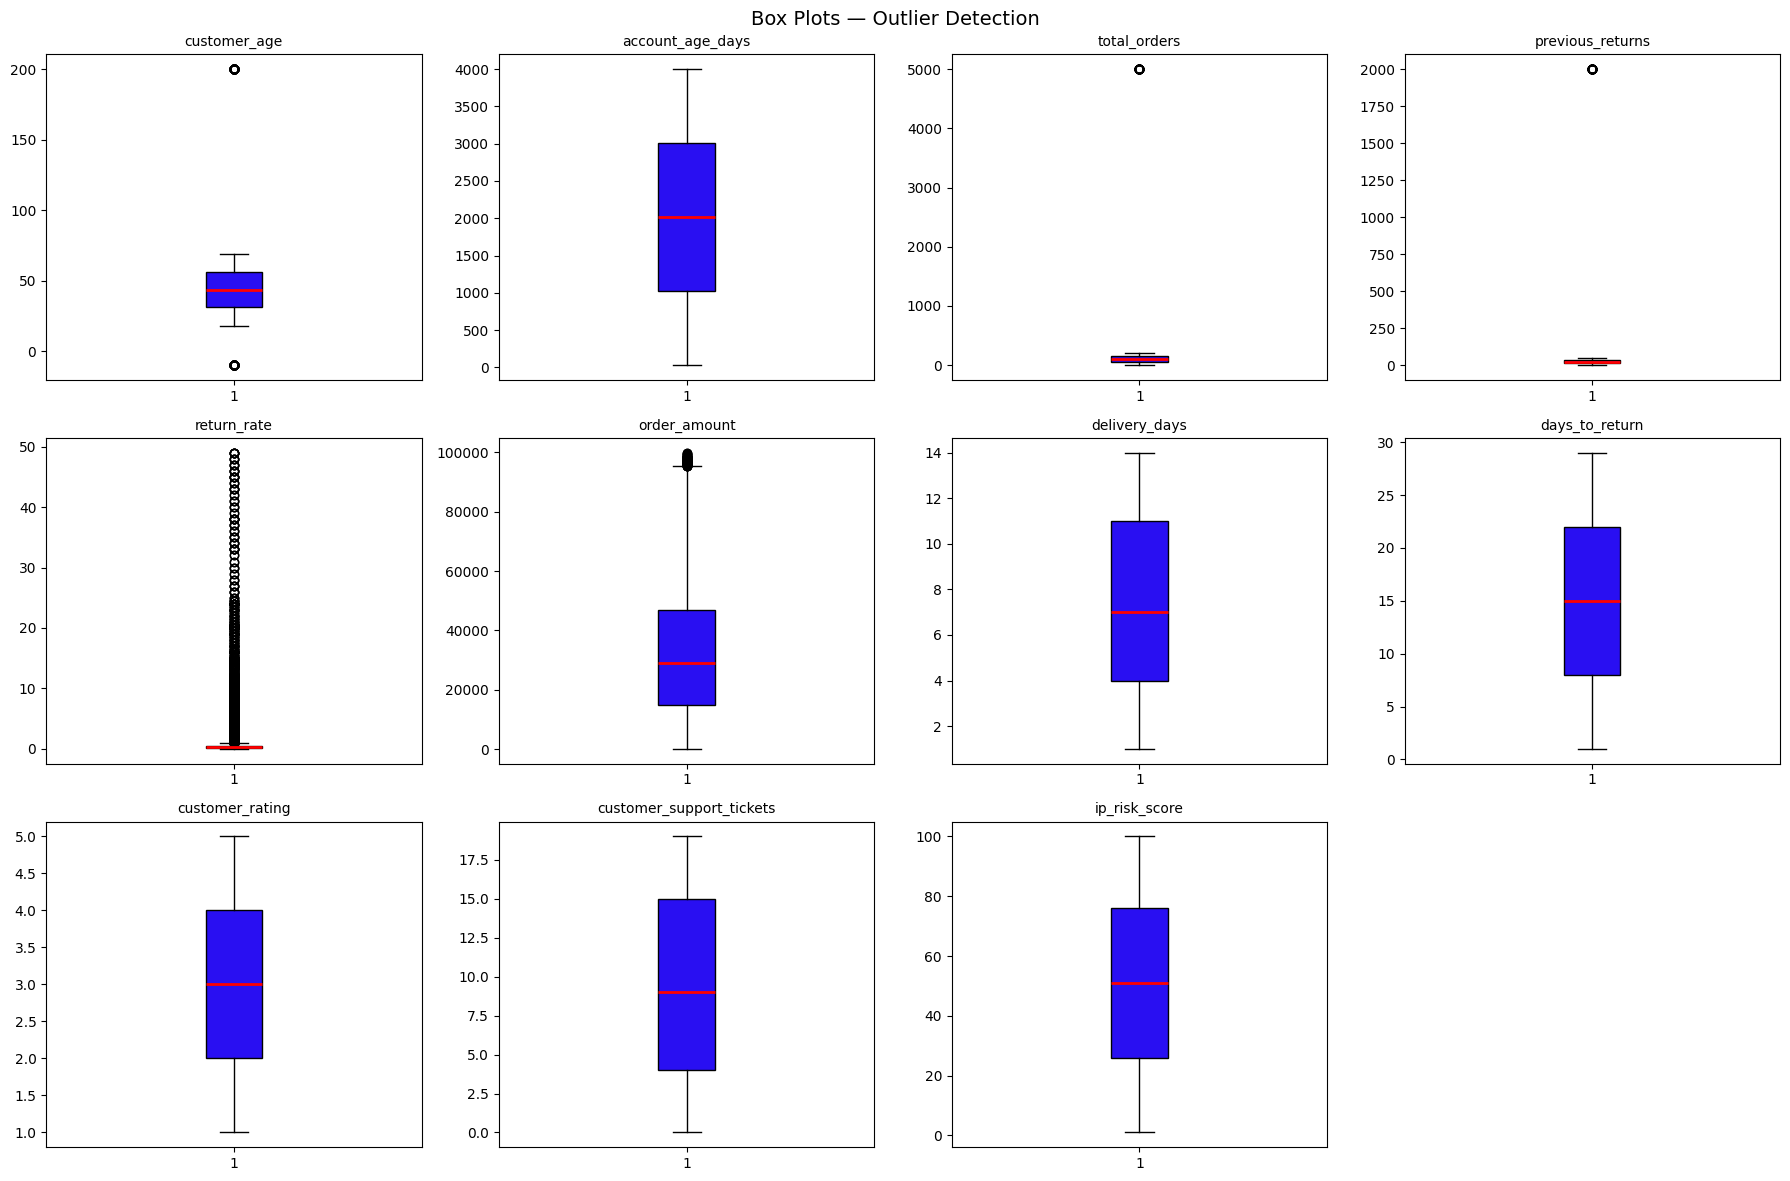

In [17]:
#Box-plot outliers
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#290ff2", color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)


if len(numeric_cols) < len(axes):
    for j in range(len(numeric_cols), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection', fontsize=14)
plt.tight_layout()
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\outlier_boxplots.png')
plt.show()




-- `return_rate` is the most critical column — 5,822 outliers (11.53%) with values exceeding 100%, which is mathematically impossible.

--  `customer_age` has 201 outliers — values like 0 or 150+ years are clearly bad data entries.

--  `order_amount` has 68 outliers — mostly sentinel/dummy values like 99,999,999 stuffed into the dataset.

--  `total_orders` and `previous_returns` each have ~50 outliers — likely the same few extreme/fraudulent customers skewing the data.

--  `delivery_days`, `days_to_return`, `customer_rating`, `customer_support_tickets`, `ip_risk_score` and `account_age_days` — all clean with zero outliers.

--  Overall only 4 out of 11 columns have outliers — dataset is largely clean, but `return_rate` alone needs urgent attention before any modelling.

## 8. Logical Consistency Checks

Verifying temporal ordering between date columns and confirming no impossible values exist in count-type fields.

In [18]:
#Date logic checks
print("LOGICAL CONSISTENCY CHECKS")

print("""
DATE LOGIC ISSUES TO CHECK IN PREPROCESSING:
1. delivery_date should be > order_date
2. return_request_date should be > delivery_date  
3. refund_processed_date should be > return_request_date
4. days_to_return should match return_request_date - delivery_date

These will be validated after date standardization in Step 3.
""")

# customer_support_tickets — 0 is fine, negative is wrong
print("customer_support_tickets — negative values:")
neg_tickets = df[df['customer_support_tickets'] < 0]
print(f"Count: {len(neg_tickets)}")

# delivery_days — 0 or negative is wrong
print("\ndelivery_days — zero or negative:")
bad_delivery = df[df['delivery_days'] <= 0]
print(f"Count: {len(bad_delivery)}")

LOGICAL CONSISTENCY CHECKS

DATE LOGIC ISSUES TO CHECK IN PREPROCESSING:
1. delivery_date should be > order_date
2. return_request_date should be > delivery_date  
3. refund_processed_date should be > return_request_date
4. days_to_return should match return_request_date - delivery_date

These will be validated after date standardization in Step 3.

customer_support_tickets — negative values:
Count: 0

delivery_days — zero or negative:
Count: 0


---
## Data Quality Summary

Consolidated findings across all 8 checks — direct input to the cleaning strategy in `data_cleaning.ipynb`.

In [19]:
print("COMPLETE DATA QUALITY REPORT")

report = []
report.append("E-COMMERCE FRAUD DETECTION — DATA QUALITY REPORT")

# 1. Missing Values
report.append("\n1. MISSING VALUES:")
for col in df.columns:
    missing = df[col].isnull().sum()
    if missing > 0:
        pct = round(missing/len(df)*100, 2)
        report.append(f"   {col}: {missing} missing ({pct}%)")

# 2. Data Type Issues
report.append("\n2. DATA TYPE ISSUES:")
report.append("   product_price: object (should be float) — ₹ symbol present")
report.append("   discount_percent: object (should be float) — % symbol present")

# 3. Categorical Inconsistencies
report.append("\n3. CATEGORICAL INCONSISTENCIES:")
report.append("   gender: Multiple formats (Male/M/male/MALE/Female/F/female)")
report.append("   membership_type: Multiple formats (Gold/GOLD/gold/Gld)")

# 4. Invalid Values
invalid_rr = len(df[df['return_rate'] > 1.0])
report.append("\n4. INVALID VALUES:")
report.append(f"   return_rate > 1.0: {invalid_rr} rows")
report.append("   product_price = 99999999: data entry error")

# 5. Date Format Issues
report.append("\n5. DATE FORMAT ISSUES:")
report.append("   All 4 date columns have mixed formats")
report.append("   Formats found: YYYY-MM-DD, Mon-DD-YYYY, MM/DD/YYYY, DD/MM/YYYY, MM-DD-YYYY")

# 6. Outliers
report.append("\n6. OUTLIER SUMMARY:")
for item in outlier_summary:
    if item['Outlier Count'] > 0:
        report.append(
            f"   {item['Column']}: {item['Outlier Count']} outliers ({item['Outlier %']}%)"
        )

# 7. Duplicates
report.append(f"\n7. DUPLICATES:")
report.append(f"   Full duplicate rows: {df.duplicated().sum()}")
report.append(f"   Duplicate order_ids: {df['order_id'].duplicated().sum()}")

report_text = "\n".join(report)
print(report_text)

# Save report
with open(r'D:\projects\commerce dataset\E-commerce\reports\data_quality_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)


COMPLETE DATA QUALITY REPORT
E-COMMERCE FRAUD DETECTION — DATA QUALITY REPORT

1. MISSING VALUES:
   customer_age: 7529 missing (14.91%)
   membership_type: 6750 missing (13.37%)
   product_price: 6516 missing (12.9%)
   customer_rating: 7575 missing (15.0%)

2. DATA TYPE ISSUES:
   product_price: object (should be float) — ₹ symbol present
   discount_percent: object (should be float) — % symbol present

3. CATEGORICAL INCONSISTENCIES:
   gender: Multiple formats (Male/M/male/MALE/Female/F/female)
   membership_type: Multiple formats (Gold/GOLD/gold/Gld)

4. INVALID VALUES:
   return_rate > 1.0: 5935 rows
   product_price = 99999999: data entry error

5. DATE FORMAT ISSUES:
   All 4 date columns have mixed formats
   Formats found: YYYY-MM-DD, Mon-DD-YYYY, MM/DD/YYYY, DD/MM/YYYY, MM-DD-YYYY

6. OUTLIER SUMMARY:
   customer_age: 201 outliers (0.4%)
   total_orders: 51 outliers (0.1%)
   previous_returns: 50 outliers (0.1%)
   return_rate: 5822 outliers (11.53%)
   order_amount: 68 outl


| # | Check | Key Finding |
|---|---|---|
| 1 | Missing Values | 4 columns — 12.9% to 15.0% missing |
| 2 | Duplicate Records | 500 exact duplicates + 500 duplicate `order_id` |
| 3 | Data Type Issues | `product_price` & `discount_percent` stored as `str` |
| 4 | Invalid Values | 5,935 impossible `return_rate` + sentinel prices + bad ages |
| 5 | Categorical Consistency | `gender` (5 variants), `membership_type` (6 variants) |
| 6 | Date Format | Mixed `YYYY-MM-DD` / `MM/DD/YYYY` in all 4 date cols |
| 7 | Outliers | `return_rate` 11.5% outliers; rest < 0.15% |
| 8 | Logical Consistency | Date order & field range checks |